
# ReFRAME Diversity Reduction Workflow for HbS (2HBS) and PKR (8TBT)

This notebook:

1. Loads the standardized ReFRAME SMILES dataset.
2. Calculates physicochemical descriptors:
   - MolWt
   - LogP
   - HBD
   - HBA
   - TPSA
3. Applies Lipinski filtering.
4. Performs Bemis-Murcko scaffold analysis.
5. Generates Morgan fingerprints.
6. Clusters compounds using k-Means.
7. Selects representative compounds nearest to cluster centroids.
8. Exports docking-ready CSV files.
9. Searches for possible positive controls by name matching.

Recommended output size for a modest workstation:
- 500–1000 representatives for docking
- 200–300 representatives for pilot docking


In [1]:

import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import rdFingerprintGenerator

from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

from tqdm import tqdm

tqdm.pandas()


In [2]:

INPUT_CSV = "skc_outputs/reframe_std.csv"

df = pd.read_csv(INPUT_CSV)

print(df.shape)
df.head()


(12056, 7)


,std_smiles,heavy_atom_count,pains_alert_count,pains_alert_names,smiles,name,source_id
0,COc1cc2ncnc(Oc3cccc(NC(=O)Nc4cc(C(C)(C)C(F)(F)...,37.0,0.0,NaN,COc1cc2ncnc(Oc3cccc(NC(=O)Nc4cc(C(C)(C)C(F)(F)...,RXDX-105,S8015
1,CC(O)C(O)c1cnc2[nH]c(N)nc(=O)c2n1,17.0,0.0,NaN,C[C@H](O)C(=O)C1=Nc2c(nc(N)[nH]c2=O)NC1,Sepiapterin,S154
2,CNC(=O)c1cc(COc2nnc(Nc3ccc(Cl)cc3)c3ccoc23)ccn1,29.0,0.0,NaN,CNC(=O)c1cc(COc2nnc(Nc3ccc(Cl)cc3)c3ccoc23)ccn1,telatinib,AZM14898
3,O=C(O)c1ccccc1OP(=O)(O)O,14.0,0.0,NaN,O=C(O)c1ccccc1OP(=O)(O)O,fosfosal,F9995-1274
4,CC(C)c1nc(CN(C)C(=O)NC(C(=O)N[C@@H](Cc2ccccc2)...,50.0,0.0,NaN,CC(C)c1nc(CN(C)C(=O)N[C@H](C(=O)N[C@@H](Cc2ccc...,RITONAVIR,155213-67-5


In [3]:

def calc_props(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return pd.Series([np.nan]*6)

    return pd.Series([
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.TPSA(mol),
        mol.GetNumHeavyAtoms()
    ])

df[["MolWt","LogP","HBD","HBA","TPSA","HeavyAtoms"]] = (
    df["std_smiles"].progress_apply(calc_props)
)

df = df.dropna(subset=["MolWt"])

print(df.shape)


100%|██████████| 12056/12056 [00:29<00:00, 405.42it/s]

(12056, 13)


In [4]:

lipinski = (
    (df["MolWt"] <= 500) &
    (df["LogP"] <= 5) &
    (df["HBD"] <= 5) &
    (df["HBA"] <= 10)
)

filtered = df[lipinski].copy()

print("Original:", len(df))
print("Lipinski:", len(filtered))
print("Retention %:", round(100*len(filtered)/len(df),2))


Original: 12056
Lipinski: 8543
Retention %: 70.86


In [6]:

def get_scaffold(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

filtered["MurckoScaffold"] = (
    filtered["std_smiles"].progress_apply(get_scaffold)
)

filtered = filtered.dropna(subset=["MurckoScaffold"])

scaffold_counts = (
    filtered["MurckoScaffold"]
    .value_counts()
    .reset_index()
)

scaffold_counts.columns = ["Scaffold","Count"]

print("Unique scaffolds:", scaffold_counts.shape[0])

scaffold_counts.head(20)


100%|██████████| 8543/8543 [00:06<00:00, 1323.49it/s]


Unique scaffolds: 4906


,Scaffold,Count
0,c1ccccc1,523
1,,232
2,O=c1ccn(C2CCCO2)c(=O)[nH]1,118
3,c1ncc2ncn(C3CCCO3)c2n1,114
4,O=c1ncccn1C1CCCO1,100
5,c1ncc2ccn(C3CCCO3)c2n1,57
6,c1ccncc1,40
7,c1ccc(Cc2ccccc2)cc1,40
8,O=C1CCC2C(=CCC3C4CCCC4CCC23)C1,35
9,c1ncc2nc[nH]c2n1,34



## Optional scaffold reduction

Keep at most 5 compounds per scaffold.

This prevents very large scaffold families from dominating the docking campaign.


In [8]:

MAX_PER_SCAFFOLD = 5

diverse_scaffold_set = (
    filtered
    .groupby("MurckoScaffold", group_keys=False)
    .head(MAX_PER_SCAFFOLD)
    .reset_index(drop=True)
)

print(diverse_scaffold_set.shape)


(6628, 14)


In [9]:

fpgen = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

def fp_array(smiles):

    mol = Chem.MolFromSmiles(smiles)

    fp = fpgen.GetFingerprint(mol)

    arr = np.zeros((2048,), dtype=np.int8)

    for bit in fp.GetOnBits():
        arr[bit] = 1

    return arr

X = np.vstack(
    diverse_scaffold_set["std_smiles"]
    .progress_apply(fp_array)
)

print(X.shape)


100%|██████████| 6628/6628 [00:09<00:00, 735.13it/s]

(6628, 2048)



## k-Means clustering

Suggested values:

| Docking Budget | Clusters |
|---|---:|
| ~200 compounds | 200 |
| ~500 compounds | 500 |
| ~1000 compounds | 1000 |


In [10]:

N_CLUSTERS = 500

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(X)

diverse_scaffold_set["Cluster"] = labels

closest_idx, distances = pairwise_distances_argmin_min(
    kmeans.cluster_centers_,
    X
)

representatives = (
    diverse_scaffold_set.iloc[closest_idx]
    .copy()
    .reset_index(drop=True)
)

print(representatives.shape)
representatives.head()


(500, 15)


,std_smiles,heavy_atom_count,pains_alert_count,pains_alert_names,smiles,name,source_id,MolWt,LogP,HBD,HBA,TPSA,HeavyAtoms,MurckoScaffold,Cluster
0,CO/N=C1/CC(C(=O)NC[C@@H](O)c2ccccc2)N(C(=O)c2c...,35.0,0.0,NaN,CO/N=C1/C[C@@H](C(=O)NC[C@@H](O)c2ccccc2)N(C(=...,NaN,CBR-HVAC-07480_B,471.557,3.72872,2.0,5.0,91.23,35.0,N=C1CC(C(=O)NCCc2ccccc2)N(C(=O)c2ccc(-c3ccccc3...,0
1,Oc1ccc(OCc2ccccc2)cc1,15.0,0.0,NaN,Oc1ccc(OCc2ccccc2)cc1,MBEH,J91436,200.237,2.97120,1.0,2.0,29.46,15.0,c1ccc(COc2ccccc2)cc1,1
2,NC[C@H]1OC2(CCCC2)O[C@@H]1CN,13.0,0.0,NaN,O=C1CC(=O)O[Pt]2(NC[C@H]3OC4(CCCC4)O[C@@H]3CN2)O1,SKI 2054R,CBR-HVAC-10766,186.255,-0.04190,2.0,4.0,70.50,13.0,C1CCC2(C1)OCCO2,2
3,COC(=O)C(c1ccccc1)C1CCCCN1,17.0,0.0,NaN,COC(=O)C(c1ccccc1)C1CCCCN1,methylphenidate HCl,HY-B1091A,233.311,2.08530,1.0,3.0,38.33,17.0,c1ccc(CC2CCCCN2)cc1,3
4,OC(CCN1CCCCC1)(c1ccccc1)c1ccccc1,22.0,0.0,NaN,OC(CCN1CCCCC1)(c1ccccc1)c1ccccc1,PRIDINOL,AG-680/20240026,295.426,3.79850,1.0,2.0,23.47,22.0,c1ccc(C(CCN2CCCCC2)c2ccccc2)cc1,4


In [11]:

representatives.to_csv(
    "skc_outputs/ReFRAME_cluster_representatives.csv",
    index=False
)

diverse_scaffold_set.to_csv(
    "skc_outputs/ReFRAME_scaffold_filtered.csv",
    index=False
)

filtered.to_csv(
    "skc_outputs/ReFRAME_lipinski_filtered.csv",
    index=False
)

print("Files written successfully.")


Files written successfully.


/tmp/ipykernel_1506/1329568360.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


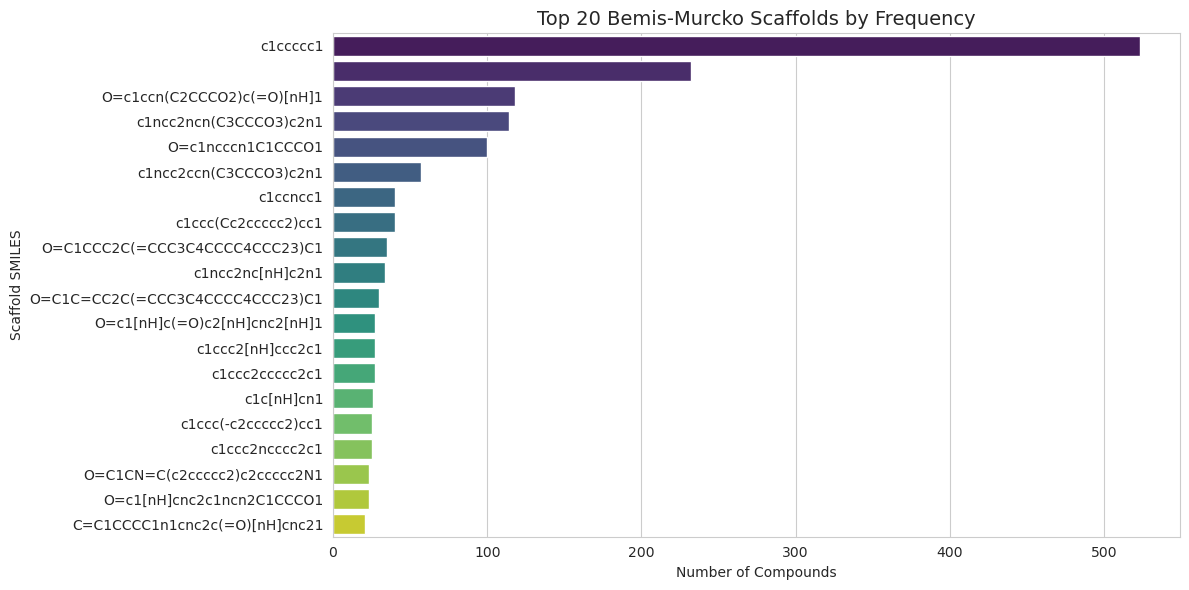

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# top scaffolds bar chat plot
sns.set_style("whitegrid")
top_n = 20
top_scaffolds = scaffold_counts.head(top_n)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=top_scaffolds,
    x="Count",
    y="Scaffold",
    palette="viridis",
    ax=ax
)
ax.set_title(f"Top {top_n} Bemis-Murcko Scaffolds by Frequency", fontsize=14)
ax.set_xlabel("Number of Compounds")
ax.set_ylabel("Scaffold SMILES")
plt.tight_layout()
plt.savefig("skc_outputs/top_scaffolds.png", dpi=150, bbox_inches="tight")
plt.show()

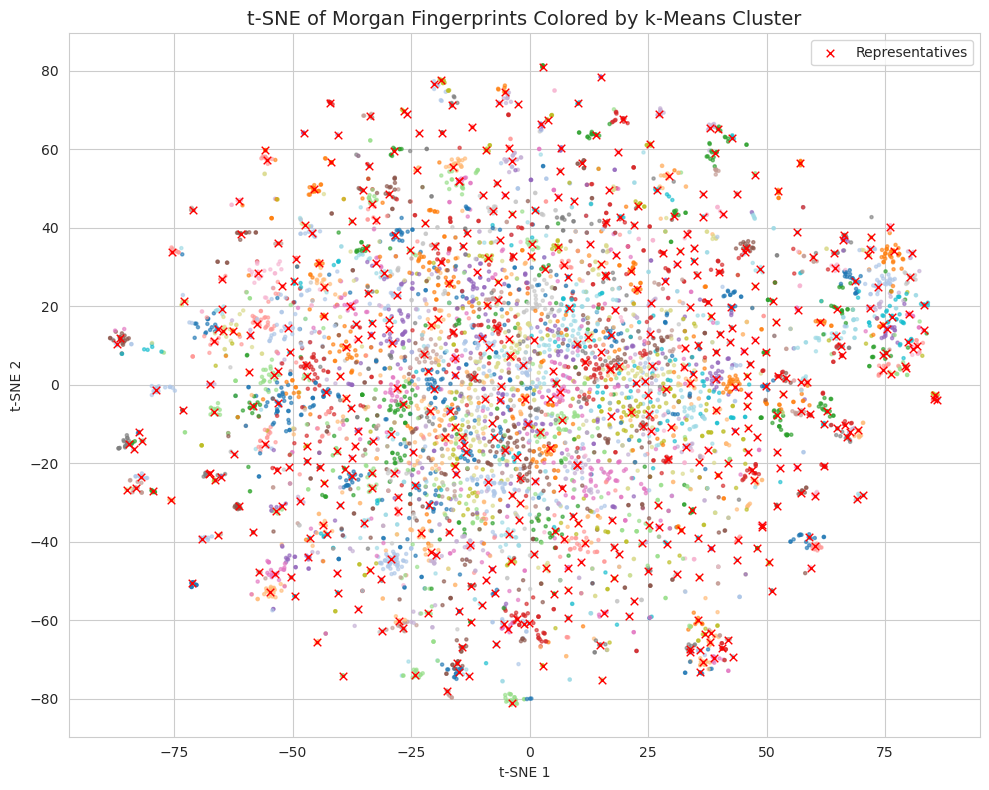

In [14]:
# t-SNE plot, coloured by cluster
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    max_iter=1000
)

X_2d = tsne.fit_transform(X)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=labels,
    cmap="tab20",
    s=5,
    alpha=0.6
)

# Highlight cluster representatives
rep_2d = X_2d[closest_idx]
ax.scatter(
    rep_2d[:, 0],
    rep_2d[:, 1],
    c="red",
    marker="x",
    s=30,
    linewidths=1,
    label="Representatives"
)

ax.set_title("t-SNE of Morgan Fingerprints Colored by k-Means Cluster", fontsize=14)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("tsne_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

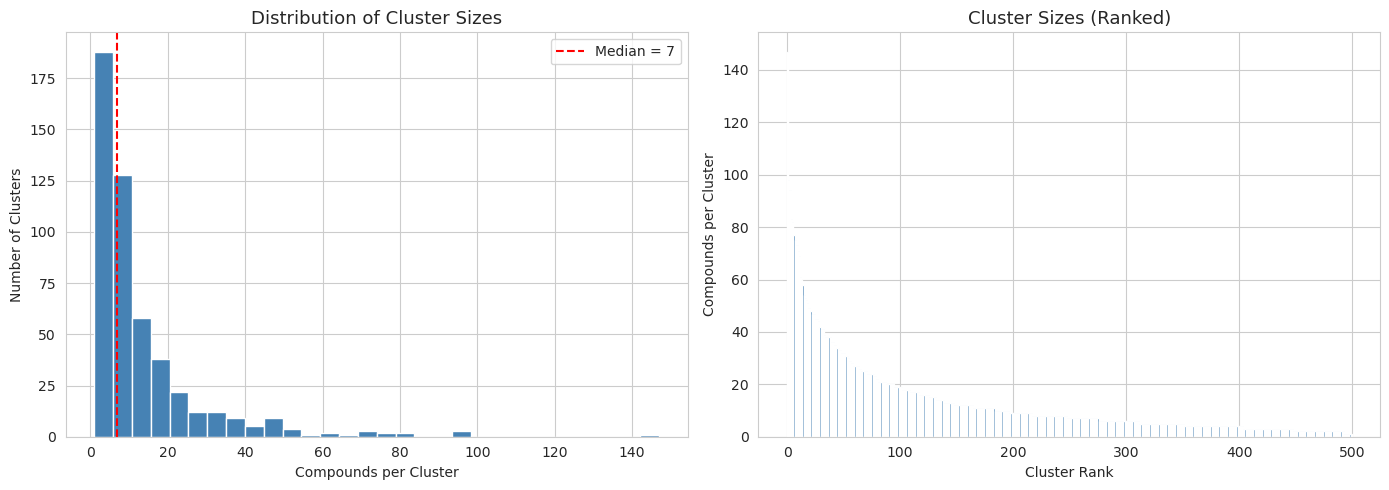

Cluster size — min: 1, max: 147, median: 7, mean: 13.3


In [15]:
# cluster size distribution

cluster_sizes = pd.Series(labels).value_counts().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(cluster_sizes.values, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Cluster Sizes", fontsize=13)
axes[0].set_xlabel("Compounds per Cluster")
axes[0].set_ylabel("Number of Clusters")
axes[0].axvline(
    cluster_sizes.median(),
    color="red",
    linestyle="--",
    label=f"Median = {cluster_sizes.median():.0f}"
)
axes[0].legend()

# Ranked bar chart
axes[1].bar(
    range(len(cluster_sizes)),
    cluster_sizes.values,
    color="steelblue",
    width=1.0
)
axes[1].set_title("Cluster Sizes (Ranked)", fontsize=13)
axes[1].set_xlabel("Cluster Rank")
axes[1].set_ylabel("Compounds per Cluster")

plt.tight_layout()
plt.savefig("skc_outputs/cluster_size_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Cluster size — min: {cluster_sizes.min()}, "
      f"max: {cluster_sizes.max()}, "
      f"median: {cluster_sizes.median():.0f}, "
      f"mean: {cluster_sizes.mean():.1f}")


## Candidate positive controls

The code below searches the ReFRAME names for compounds reported in the literature as:

### HbS / antisickling examples
- voxelotor
- tucaresol
- 5-HMF
- vanillin
- piracetam

### PKR activator examples
- DHBDC
- BEPP
- kinetin-riboside

Add more names if desired.


In [16]:

positive_controls = [
    "voxelotor",
    "tucaresol",
    "vanillin",
    "5-hmf",
    "piracetam",
    "dhbdc",
    "bepp",
    "kinetin",
    "mitapivat",
    "etavopivat",
    "AG-946"
]

hits = []

for term in positive_controls:

    tmp = df[
        df["name"]
        .astype(str)
        .str.contains(term, case=False, na=False)
    ]

    if len(tmp) > 0:
        hits.append(tmp)

if len(hits):
    hits = pd.concat(hits)
    display(hits[["name","source_id","std_smiles"]])
else:
    print("No obvious name matches found.")


,name,source_id,std_smiles
6275,TUCARESOL,F9994-5209,O=Cc1c(O)cccc1OCc1ccc(C(=O)O)cc1
2039,Kinetin,R052-0875,c1coc(CNc2ncnc3[nH]cnc23)c1
5036,Kinetin riboside,SS-3028-72,OC[C@H]1O[C@@H](n2cnc3c(NCc4ccco4)ncnc32)[C@H]...
10220,MitapivatÃ‚Â,HY-12689,O=C(c1ccc(NS(=O)(=O)c2cccc3cccnc23)cc1)N1CCN(C...


In [17]:
hits.to_csv("skc_outputs/controls.csv")

In [18]:
from rdkit.Chem import SDWriter
sdf_path = "skc_outputs/ReFRAME_cluster_rep_500.sdf"
writer = SDWriter(sdf_path)
prop_order = ["std_smiles", "source_id", "name", "MolWt", "LogP", "HBD", "HBA", "TPSA", "HeavyAtoms"]
for _, row in representatives.iterrows():
    mol = Chem.MolFromSmiles(row["std_smiles"])
    if mol is None:
        continue
    for prop in prop_order:
        if prop in row.index:
            mol.SetProp(prop, str(row[prop]))
    writer.write(mol)
writer.close()
print(f"Saved {len(representatives)} molecules to {sdf_path}")

Saved 500 molecules to skc_outputs/ReFRAME_cluster_rep_500.sdf


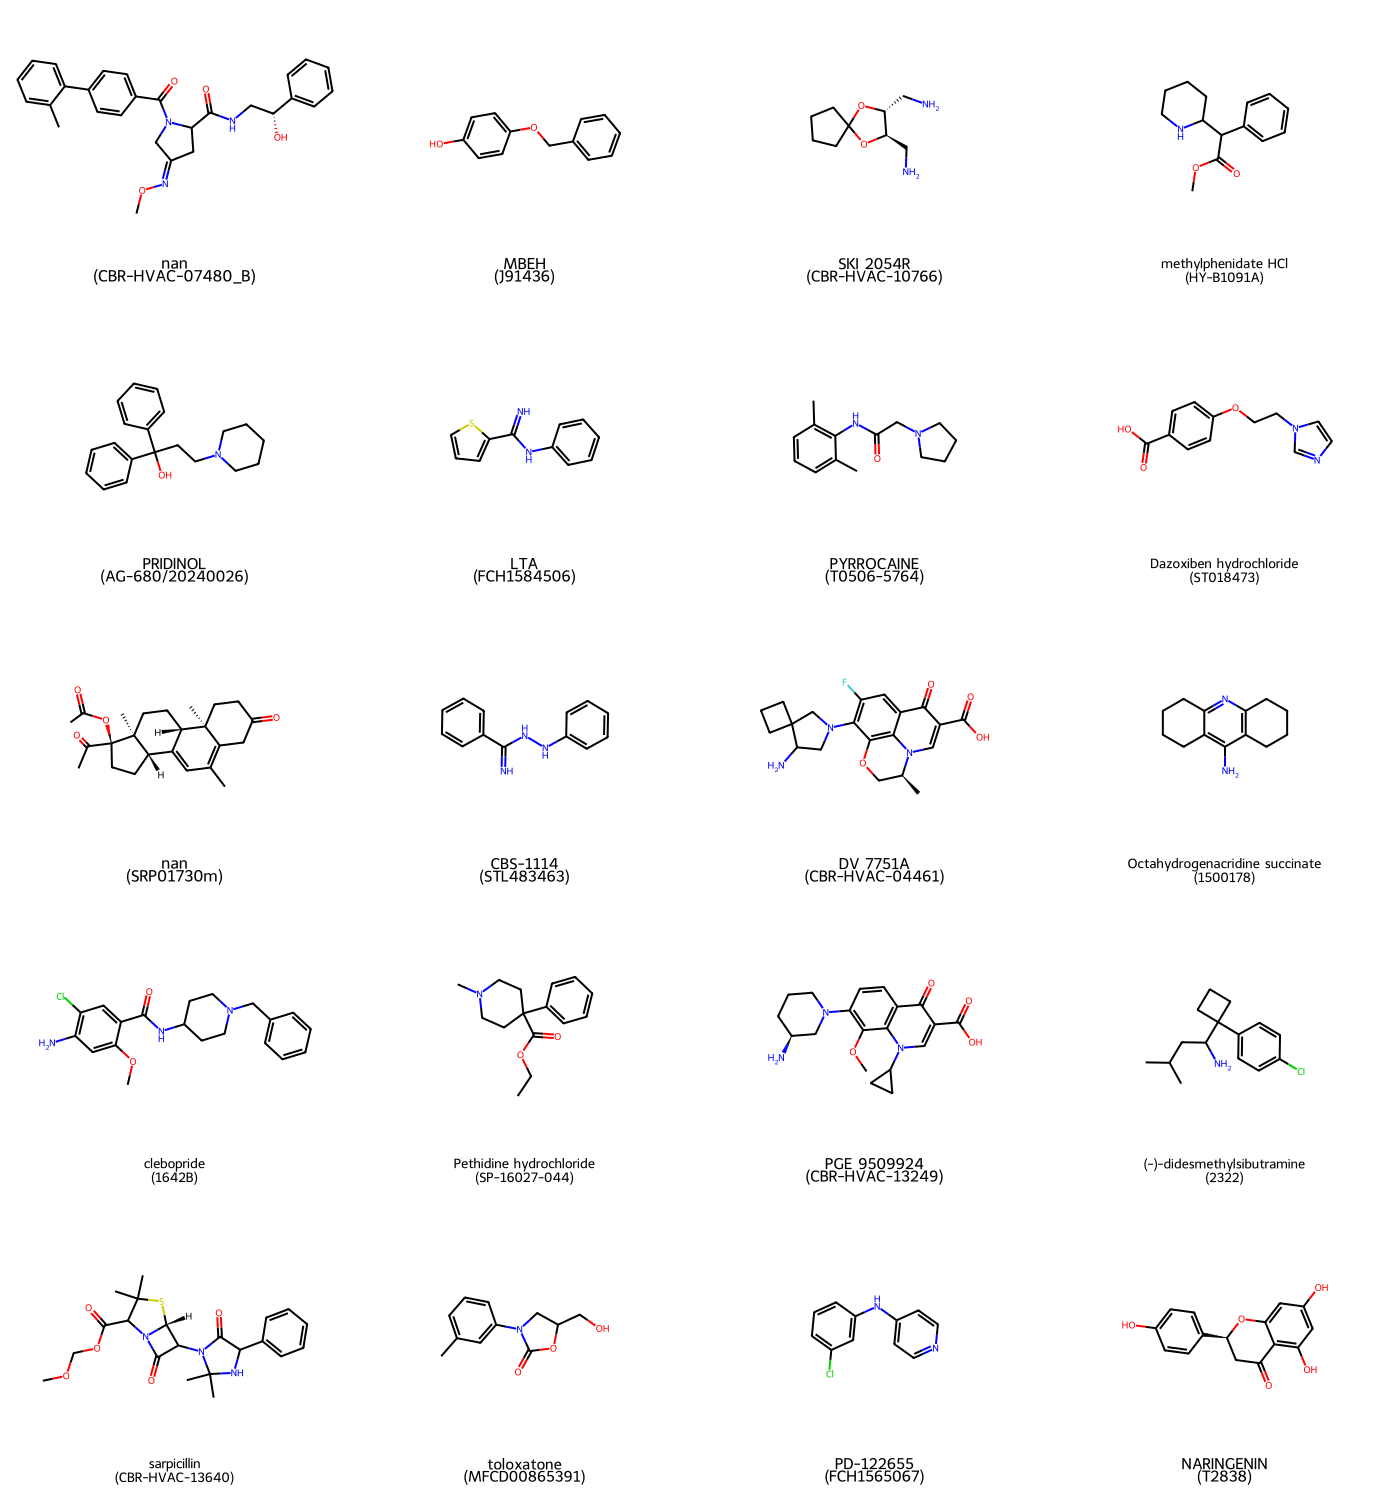

In [22]:
from rdkit.Chem import Draw

top20 = representatives.head(20)
mols = [Chem.MolFromSmiles(s) for s in top20["std_smiles"]]
legends = [
    f"{row['name']}\n({row['source_id']})"
    for _, row in top20.iterrows()
]
img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(350, 300),
    legends=legends
)
# img.save("skc_outputs/top20_representatives.png")
img